Sheet 1.1: Backpropagation from Scratch with Micrograd
===
**Author**: Amir Mohammadpour

Every modern deep learning framework contains an automatic differentiation engine at its core. When a network is trained, something computes the gradient of the loss with respect to every parameter. That computation is what makes gradient-based learning possible, yet it is rarely examined directly, because frameworks abstract it away behind a single method call.

This tutorial removes that abstraction. The goal is to understand how automatic differentiation actually works — what data structures it relies on, what the chain rule looks like when implemented explicitly, and why the steps of a training loop must happen in the order they do. These are things that are easy to take for granted when a framework handles them invisibly, and worth understanding carefully before it does.

The vehicle is a minimal autograd engine in pure Python that operates on scalar values only. Scalars make it impractical at any real scale, but they also make everything visible: every gradient is an explicit Python value, every operation is a readable function, and the computation graph is a data structure you can inspect and draw. Nothing happens behind the scenes. This engine was originally developed by Andrej Karpathy as a teaching tool, and it remains one of the clearest expositions of the core ideas.

The tutorial proceeds in four parts: the `Value` class and the computation graph, a forward pass through an explicit two-layer MLP, a first exercise on implementing a backward rule from scratch, and a second exercise on writing a complete training loop. Solutions are provided below each exercise and should not be consulted until an honest attempt has been made.

> **Source.** The `Value` class below is taken from Karpathy's lecture notebook [`micrograd_lecture_second_half_roughly.ipynb`](https://github.com/karpathy/nn-zero-to-hero/blob/master/lectures/micrograd/micrograd_lecture_second_half_roughly.ipynb), part of the [Neural Networks: Zero to Hero](https://github.com/karpathy/nn-zero-to-hero) series (see also [github.com/karpathy/micrograd](https://github.com/karpathy/micrograd)), with almost zero modification.

To begin the beginning, let's import the packages we will use further down this notebook.

In [1]:
import math
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

---
## 1 . The Computation Graph

Consider the expression `e = a * b + c`. Evaluated in plain Python, it produces a number; the intermediate steps are computed and immediately discarded. For automatic differentiation, this is insufficient. What is needed is a record of *how* `e` was produced — which values were combined, and by which operations — so that one can later answer the question: by how much does `e` change if `a` is perturbed slightly?

The solution is to wrap each scalar in an object that, in addition to its numeric value, records its computational history: which operation created it, and from which inputs. Ordinary arithmetic expressions written in terms of these wrapped scalars then assemble a **computation graph** as a side effect of evaluation. Each node in the graph holds one scalar; each directed edge points from an input to the operation that consumed it. Computing gradients reduces to a single backward traversal of this graph, applying the chain rule at each node in reverse topological order — from outputs back to inputs.

The `Value` class below is the complete engine. Read it in full before running anything.

In [2]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out
  
  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers"
    out = Value(self.data**other, (self,), f'**{other}')
    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward
    return out
  
  def __rmul__(self, other): return self * other
  def __truediv__(self, other): return self * other**-1
  def __neg__(self): return self * -1
  def __sub__(self, other): return self + (-other)
  def __radd__(self, other): return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    return out
  
  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    def _backward():
      raise NotImplementedError("Your task: implement the backward pass for exp")
    out._backward = _backward
    return out
  
  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

### The fields of a `Value` node

The implementation above realises the idea outlined earlier: scalar arithmetic that simultaneously builds a computation graph.

Each `Value` object carries five attributes, all of which matter for what follows.

**`.data`** holds the raw scalar. All arithmetic — addition, multiplication, and so on — is computed here in the ordinary sense.

**`.grad`** holds the gradient of the final output with respect to this node, i.e., $\partial L / \partial \text{self}$. It is initialised to zero and populated during the backward pass.

Each operation also defines a **`_backward`** closure that encodes its local derivative:
> - For addition, gradients are passed through unchanged.
> - For multiplication, each input receives the other input’s value, reflecting the product rule.
> - For powers and nonlinearities such as tanh, the corresponding analytical derivatives are embedded directly in the closure.

No gradients are computed during the forward pass. Instead, every node simply stores the information required to compute them later.


**`._prev`** is the set of `Value` nodes that served as direct inputs to this one — the incoming edges in the graph.

**`._op`** is a string label recording which operation created this node. It serves no computational purpose; it is used only for visualisation.

The `backward()` method initialises the output's gradient to `1.0` — since $\partial \text{output} / \partial \text{output} = 1$ by definition — and then calls each node's `_backward` closure in reverse topological order. The ordering guarantees that when a node's closure runs, the gradient flowing in from all downstream nodes has already been accumulated into `out.grad`. The chain rule is, in this sense, enforced by the traversal order rather than by any explicit formula.

The cell below runs a forward and backward pass on `e = a * b + c`. Verify the printed gradients by hand before proceeding.

In [3]:
# Build the expression e = a * b + c
a = Value(2.0,   label='a')
b = Value(-3.0,  label='b')
c = Value(10.0,  label='c')

ab = a * b;  ab.label = 'a*b'
e  = ab + c; e.label  = 'e'

# Run backward to populate .grad at every node
e.backward()

print(f"e = {e.data}")
print(f"de/da = {a.grad}  (expected {b.data})")
print(f"de/db = {b.grad}  (expected {a.data})")
print(f"de/dc = {c.grad}  (expected 1.0)")

e = 4.0
de/da = -3.0  (expected -3.0)
de/db = 2.0  (expected 2.0)
de/dc = 1.0  (expected 1.0)


Once you’ve done it the hard (manual) way, run the cells below. It will give you a visual representation of the computation graph, where each node corresponds to a scalar, and each directed edge represents the flow of computation from inputs to output, including both forward values and backward gradients at each node.

This visualisation makes the abstract graph concrete: one can inspect both the forward values and the gradients after a backward pass, and verify how local derivative rules combine across the graph.

In [4]:
def draw_dot(root):
    """Visualise a micrograd computation graph with matplotlib."""
    from collections import deque

    nodes, edges = set(), set()
    def _trace(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                _trace(child)
    _trace(root)

    level = {root: 0}
    queue = deque([root])
    while queue:
        v = queue.popleft()
        for child in v._prev:
            nl = level[v] + 1
            if child not in level or level[child] < nl:
                level[child] = nl
                queue.append(child)
    max_level = max(level.values()) if level else 0

    by_col = defaultdict(list)
    for v in nodes:
        by_col[max_level - level[v]].append(v)
    for col in by_col:
        by_col[col].sort(key=lambda v: id(v))

    X_GAP, Y_GAP = 4.0, 2.0
    pos = {}
    for col, grp in by_col.items():
        n = len(grp)
        for i, v in enumerate(grp):
            pos[v] = (col * X_GAP, -(i - (n - 1) / 2) * Y_GAP)

    all_x = [p[0] for p in pos.values()]
    all_y = [p[1] for p in pos.values()]
    x_lo, x_hi = min(all_x) - X_GAP * 0.5, max(all_x) + X_GAP * 0.5
    y_lo, y_hi = min(all_y) - Y_GAP * 0.6, max(all_y) + Y_GAP * 0.6

    max_n = max(len(g) for g in by_col.values())
    fig_w = max(6, (max_level + 1) * 2.2)
    fig_h = max(3, max_n * 1.4 + 1.0)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    for src, dst in edges:
        x0, y0 = pos[src]
        x1, y1 = pos[dst]
        ax.annotate(
            "", xy=(x1, y1), xytext=(x0, y0),
            xycoords='data', textcoords='data',
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.4,
                            shrinkA=18, shrinkB=18),
            annotation_clip=False,
        )

    for v in nodes:
        x, y = pos[v]
        lbl = getattr(v, 'label', '')
        lines = []
        if lbl: lines.append(f"  {lbl}  ")
        if v._op: lines.append(f"op: {v._op}")
        lines.append(f"data = {v.data:+.4f}")
        lines.append(f"grad = {v.grad:+.4f}")
        fc = '#AED6F1' if not v._op else '#A9DFBF'
        ax.text(x, y, "\n".join(lines), ha='center', va='center', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.45', fc=fc, ec='#333', lw=1.2),
                fontfamily='monospace', zorder=3)

    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(y_lo, y_hi)
    ax.set_aspect('auto')
    ax.axis('off')
    ax.set_title('Computation Graph', fontsize=12, pad=8)
    plt.tight_layout()
    plt.show()

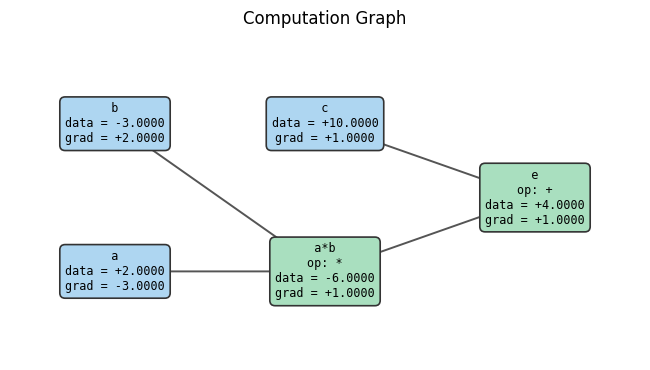

In [5]:
draw_dot(e)

---
## 2 . Forward Pass: A 2-Layer MLP

Having established how the engine works on a simple arithmetic expression, we now apply it to something that has the structure of a neural network: a two-layer MLP with two inputs, three hidden neurons with tanh activations, and one linear output.

The implementation that follows is deliberately unabstracted. No loops, no module classes — every weight, bias, pre-activation, and activation is its own named `Value` object. This is not a recommended coding practice; it is a transparency device. Written this way, each line of code corresponds to exactly one node in the computation graph, and the graph's structure is directly readable from the source. The cost is verbosity; the benefit is that nothing is hidden.

As you read through the cell, keep track of how the graph is growing with each line — how many nodes exist after the weights are defined, how many after the first layer's activations, and how many after the output. The visualisation that follows makes this concrete.

In [ ]:
# x1 ──┬───────────────┬───────────────┬
#      │               │               │
#      ▼               ▼               ▼
#    (×)             (×)             (×)
#   w11,w12         w21,w22         w31,w32
#      │               │               │
#      ▼               ▼               ▼
#    tanh            tanh            tanh
#     h1              h2              h3
#      │               │               │
#      ▼               ▼               ▼
#     (×)             (×)             (×)
#      v1              v2              v3
#        \              |              /
#         └─────────────┴─────────────┘
#                       ▼
#                       o

#TODO: redo this with graphviz or something more robust than ascii art

# ── Layer 1 weights and biases (3 neurons x 2 inputs) ────────────────────────
w11 = Value( 0.20, label='w11'); w12 = Value( 0.80, label='w12')
w21 = Value(-0.50, label='w21'); w22 = Value( 0.10, label='w22')
w31 = Value( 0.30, label='w31'); w32 = Value(-0.90, label='w32')
b1  = Value( 0.10, label='b1')
b2  = Value(-0.20, label='b2')
b3  = Value( 0.50, label='b3')

# ── Layer 2 weights and biases (1 output neuron x 3 inputs) ──────────────────
v1  = Value( 0.70, label='v1')
v2  = Value(-0.30, label='v2')
v3  = Value( 0.20, label='v3')
b_o = Value( 0.00, label='b_o')

# ── Inputs ────────────────────────────────────────────────────────────────────
x1 = Value(2.0, label='x1')
x2 = Value(3.0, label='x2')

# ── Layer 1: pre-activation and tanh ─────────────────────────────────────────
h1 = (w11 * x1 + w12 * x2 + b1).tanh(); h1.label = 'h1'
h2 = (w21 * x1 + w22 * x2 + b2).tanh(); h2.label = 'h2'
h3 = (w31 * x1 + w32 * x2 + b3).tanh(); h3.label = 'h3'

# ── Layer 2: linear output ────────────────────────────────────────────────────
o  = v1 * h1 + v2 * h2 + v3 * h3 + b_o; o.label = 'output'

print(f"h1     = {h1.data:.4f}")
print(f"h2     = {h2.data:.4f}")
print(f"h3     = {h3.data:.4f}")
print(f"output = {o.data:.4f}")

# Compute a loss (MSE against target 0.0) and run backward
target = 0.0
loss = (o - target) ** 2
loss.label = 'loss'
loss.backward()

print(f"output = {o.data:.4f},  target = {target},  loss = {loss.data:.4f}")
print(f"\nInput gradients:")
print(f"  dL/dx1 = {x1.grad:.4f}")
print(f"  dL/dx2 = {x2.grad:.4f}")
print(f"\nFirst-layer weight gradients (sample):")
print(f"  dL/dw11 = {w11.grad:.4f},  dL/dw12 = {w12.grad:.4f}")

h1     = 0.9940
h2     = -0.7163
h3     = -0.9217
output = 0.7263
output = 0.7263,  target = 0.0,  loss = 0.5276

Input gradients:
  dL/dx1 = 0.1217
  dL/dx2 = -0.0508

First-layer weight gradients (sample):
  dL/dw11 = 0.0245,  dL/dw12 = 0.0367


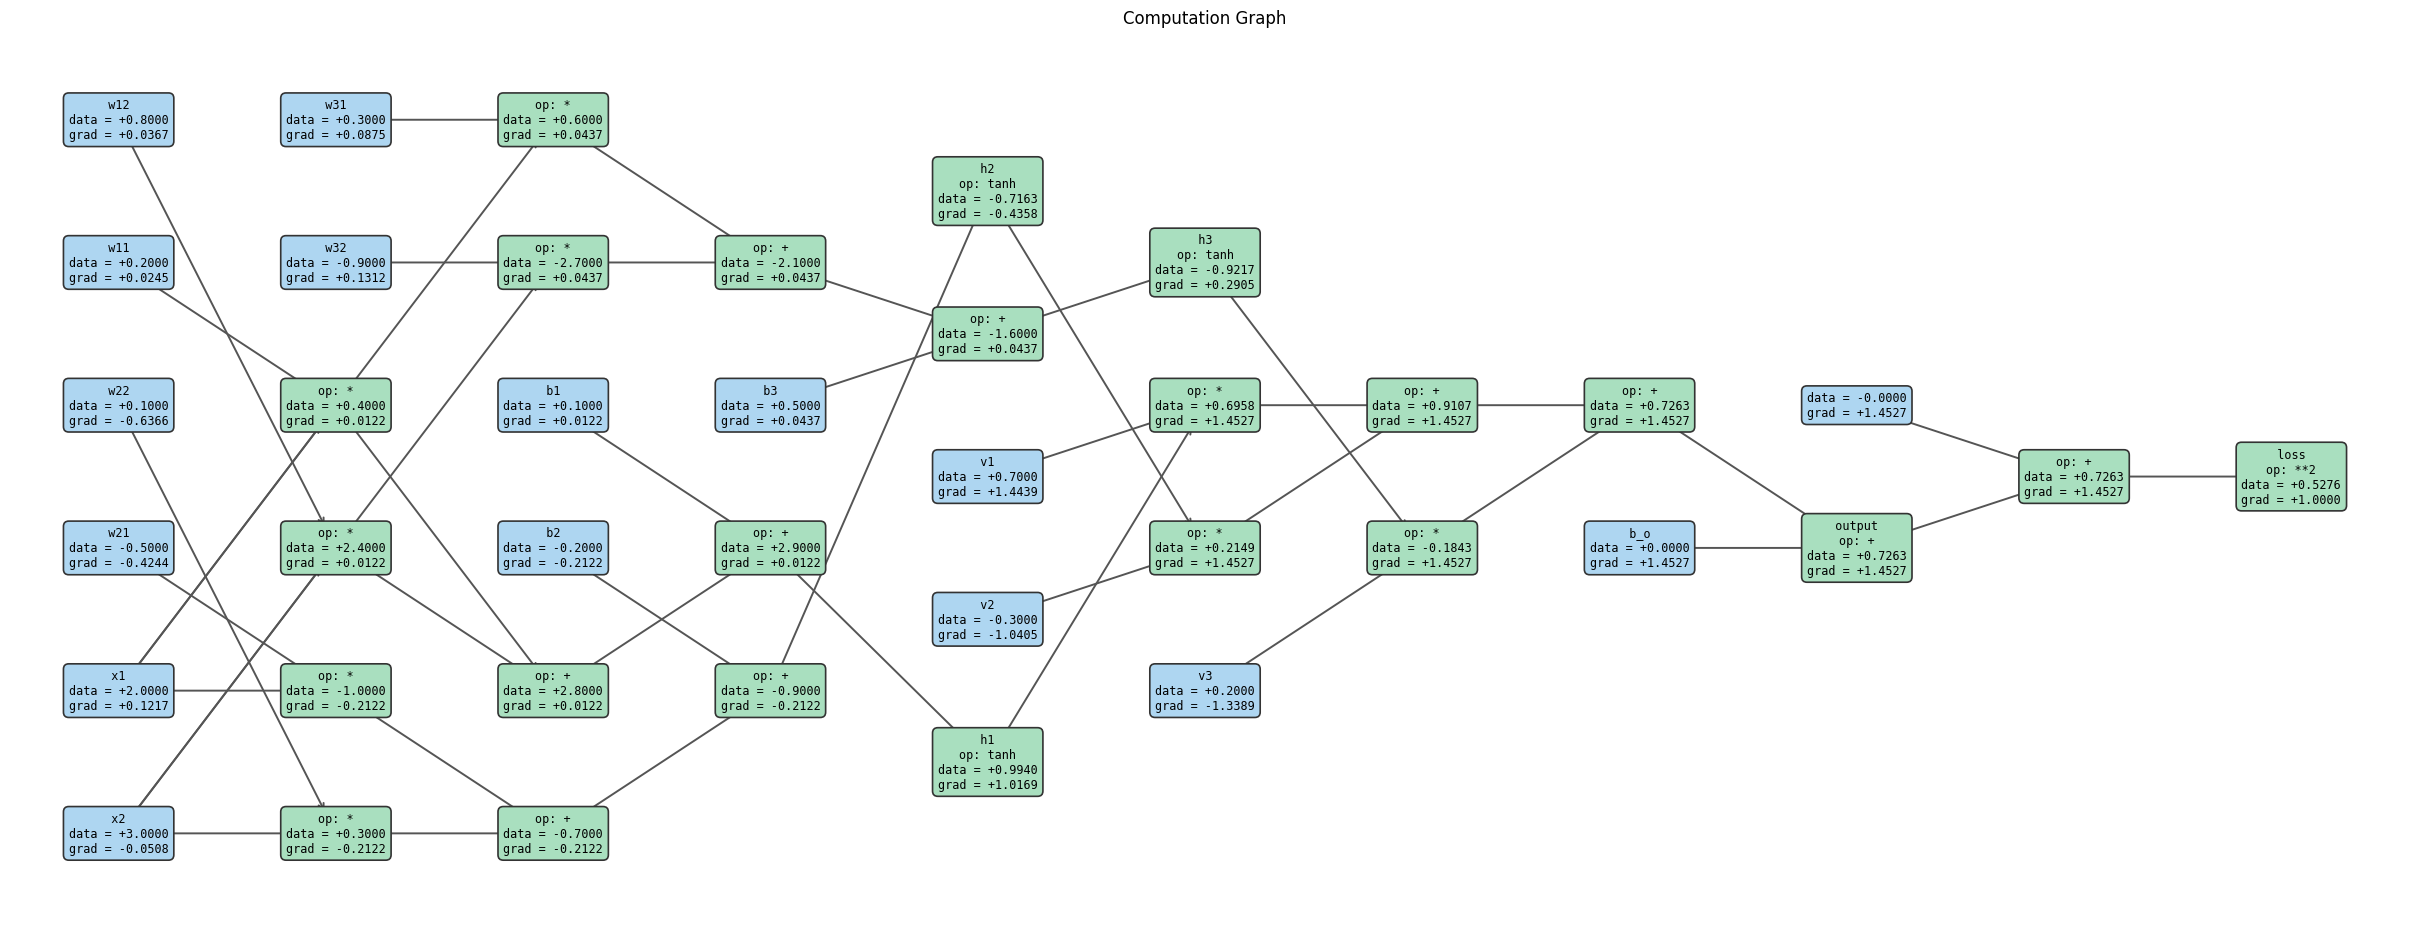

In [7]:
draw_dot(loss)

The forward pass is now complete: inputs flowed through weights and nonlinearities to produce a scalar output, and the computation graph records every step. What comes next is the backward pass — propagating gradients from the output back to every weight so that we know how to improve them.

The backward rules for addition and multiplication are already implemented in the `Value` class. The next exercise asks you to derive the rule for one further operation.


___
### Deriving a backward rule
The `Value.exp` method below computes the forward pass correctly, evaluating $e^x$ and recording the result as a new node. Its `_backward` closure, however, is unimplemented.

Every `_backward` closure has the same responsibility: given `out.grad` — the gradient of the final loss with respect to the output of this operation, assumed already computed — determine how much of that gradient is attributable to each input, and add the result onto that input's `.grad`. The chain rule gives the general form:

$$\frac{\partial L}{\partial x} \mathrel{+}= \frac{\partial L}{\partial \text{out}} \cdot \frac{\partial\, \text{out}}{\partial x}$$

The first factor on the right is `out.grad`. The second is the local derivative, specific to this operation, which follows from calculus alone. For `exp`, the forward pass is $\text{out} = e^x$. The local derivative $d(e^x)/dx$ is a standard result; note also that it can be expressed directly in terms of `out.data`, avoiding a redundant call to `math.exp`.

The `+=` rather than `=` is not incidental. The same `Value` node may appear as an input in multiple places in the graph, and each such use contributes its own gradient. Accumulating with `+=` handles this correctly; overwriting with `=` would not.

> **Exercise 1.1.1**  
> Implement the `_backward` closure for `exp` in the cell below.  
> Run the test cell afterwards to verify your implementation against finite differences.

In [8]:
def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
        # ── your code here ──────────────────────────────────────────────────
        raise NotImplementedError("Your task: implement the backward pass for exp")
        # ────────────────────────────────────────────────────────────────────
    out._backward = _backward
    return out

# Patch onto the class so the test cell below uses your implementation
Value.exp = exp

In [9]:
# ── Finite-difference test ───────────────────────────────────────────────────
# Central difference: f'(x) ≈ (f(x+ε) - f(x-ε)) / 2ε

def numerical_grad(f, x_val, eps=1e-5):
    return (f(x_val + eps) - f(x_val - eps)) / (2 * eps)

all_passed = True
for x_val in [0.0, 0.5, -1.0, 2.0, -0.3]:
    x = Value(x_val)
    y = x.exp()
    y.backward()
    analytical = x.grad
    numerical = numerical_grad(lambda v: Value(v).exp().data, x_val)
    match = abs(analytical - numerical) < 1e-4
    all_passed = all_passed and match
    status = "PASS" if match else "FAIL"
    print(f"[{status}]  x={x_val:+.1f}  analytical={analytical:.6f}  numerical={numerical:.6f}")

print()
print("All tests passed!" if all_passed else "Some tests FAILED — check your implementation.")

NotImplementedError: Your task: implement the backward pass for exp

<details>
<summary>Show solution</summary>

```
# d/dx e^x = e^x.  The forward pass already stored e^x as out.data,
# so we reuse it instead of calling math.exp again.

def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    def _backward():
        self.grad += out.data * out.grad
    out._backward = _backward
    return out

Value.exp = exp
```
</details>

---
### The structure of a training step

Training a neural network is an iterative process: at each step, the parameters are adjusted slightly to reduce the loss on the training data. A single such step has four stages, each of which is necessary, and whose order is not arbitrary.

**Zeroing the gradients** must happen first. Because `.grad` accumulates via `+=`, gradients from previous steps persist unless explicitly reset. Failing to zero them before the forward pass causes the update to reflect a mixture of the current and all past gradients — a subtle error that is easy to miss because the loss may still decrease, only more slowly or erratically.

**The forward pass** runs the model on each input, producing predictions and — as a side effect — constructing the computation graph for this step. The graph is rebuilt from scratch each iteration, because the parameter values have changed since the last step.

**The backward pass** collapses the predictions and ground-truth labels into a single scalar loss, then traverses the computation graph in reverse and populates `.grad` on every node, including every parameter.

**The parameter update** adjusts each parameter in the direction that decreases the loss. Since `.grad` points in the direction of steepest *increase*, the update subtracts a scaled gradient:

$$\theta \leftarrow \theta - \eta \cdot \frac{\partial L}{\partial \theta}$$

In code: `p.data -= lr * p.grad`. The scalar $\eta$ is the learning rate. Its choice involves a tradeoff: too large a value causes the loss to oscillate or diverge; too small a value makes convergence unnecessarily slow.

### Dataset and model

We fit $y = x^2$ sampled at nine evenly-spaced points $x \in \{-2, -1.5, \ldots, 2\}$. The model and the `Neuron`, `Layer`, and `MLP` classes that define it are provided in the cells below — read through them before proceeding to the exercise.

In [ ]:
class Neuron:
    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(0.0)
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.tanh() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]


class Layer:
    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]


class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        # All layers use tanh except the last (linear output)
        self.layers = [
            Layer(sz[i], sz[i + 1], nonlin=(i < len(nouts) - 1))
            for i in range(len(nouts))
        ]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [ ]:
random.seed(42)

# y = x^2 sampled at nine evenly-spaced points
xs = [[-2.0], [-1.5], [-1.0], [-0.5], [0.0], [0.5], [1.0], [1.5], [2.0]]
ys = [ 4.0,    2.25,   1.0,   0.25,   0.0,  0.25,   1.0,  2.25,  4.0]

model = MLP(1, [8, 1])   # 1 input → 8 hidden (tanh) → 1 output (linear)
print(f"Total parameters: {len(model.parameters())}")

> **Exercise 1.1.2**  
> Implement `train_step` below. The function receives the model, the dataset `(xs, ys)`,
> and a learning rate `lr`. It must perform one complete training step and return the loss `Value`
> (so the caller can read `loss.data`).
>
> Use MSE loss: $L = \dfrac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2$
>
> A correct implementation will show the loss declining smoothly from roughly 3–4 to below 0.01 over 400 epochs.

In [ ]:
def train_step(model, xs, ys, lr):
    """
    One training step: zero grads → forward → MSE loss → backward → update.
    Returns the loss Value.
    """
    # ── your code here ──────────────────────────────────────────────────────
    raise NotImplementedError("Implement the training step")
    # ────────────────────────────────────────────────────────────────────────

<details>
<summary>Show solution</summary>

```
def train_step(model, xs, ys, lr):
    # 1. Zero gradients — must happen before the forward pass
    for p in model.parameters():
        p.grad = 0.0

    # 2. Forward pass: compute one prediction per input
    ypred = [model(x) for x in xs]

    # 3. MSE loss
    loss = sum((yp - yt) ** 2 for yp, yt in zip(ypred, ys)) * (1.0 / len(ys))

    # 4. Backward pass
    loss.backward()

    # 5. Gradient-descent update
    for p in model.parameters():
        p.data -= lr * p.grad

    return loss
```

</details>

In [ ]:
# Training loop — runs once train_step is implemented
random.seed(42)
model = MLP(1, [8, 1])

losses = []
N_EPOCHS = 400
LR = 0.05

for epoch in range(N_EPOCHS):
    loss = train_step(model, xs, ys, LR)
    losses.append(loss.data)
    if epoch % 50 == 0:
        print(f"epoch {epoch:4d}  loss = {loss.data:.6f}")

print(f"\nFinal loss: {losses[-1]:.6f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(losses, color='steelblue', lw=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_yscale('log')
axes[0].set_title('Training Loss (log scale)')
axes[0].grid(True, alpha=0.35)

# Predictions vs. ground truth
x_plot = np.linspace(-2.2, 2.2, 200)
y_true = x_plot ** 2
y_pred = [model([float(x)]).data for x in x_plot]

axes[1].plot(x_plot, y_true, 'k--', lw=1.5, label=r'$y = x^2$')
axes[1].plot(x_plot, y_pred, color='tomato', lw=2, label='MLP prediction')
axes[1].scatter([x[0] for x in xs], ys, zorder=5, color='steelblue', label='training data')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Fitted Function')
axes[1].legend()
axes[1].grid(True, alpha=0.35)

plt.tight_layout()
plt.show()